In [1]:
# ================================================================================
# EXPERIMENT B: EDGE DETECTOR COMPARISON
# ================================================================================
# 
# Purpose: Compare Sobel vs Prewitt vs Scharr vs Laplacian for Edge Loss
# Baseline: V3/V4 configuration with Edge Loss enabled

# ## Objective
# Compare different edge detection algorithms for Edge Loss:
# - Sobel (current baseline)
# - Prewitt (similar to Sobel, different kernel)
# - Scharr (improved gradient estimation)
# - Laplacian (second-order derivative)
# 
# ## Test Configuration
# Using Edge+Surface configuration to test edge detection effectiveness:
# - Style Weight: 1e-4
# - Edge Weight: 40,000 (enabled)
# - Surface Weight: 10,000
# - Laplacian Weight: 0


In [2]:
# 1. Imports and Setup

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
import time
import os
import csv
from datetime import datetime

# Check GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("\n GPU is available!")
    # Enable memory growth to avoid OOM
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("\n No GPU detected - running on CPU (will be slower)")

# Create results directory
RESULTS_DIR = 'results_edge_detector_comparison'
os.makedirs(RESULTS_DIR, exist_ok=True)

TensorFlow version: 2.10.1
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

 GPU is available!


Content image shape: (1, 512, 512, 3)
Style image shape: (1, 512, 512, 3)


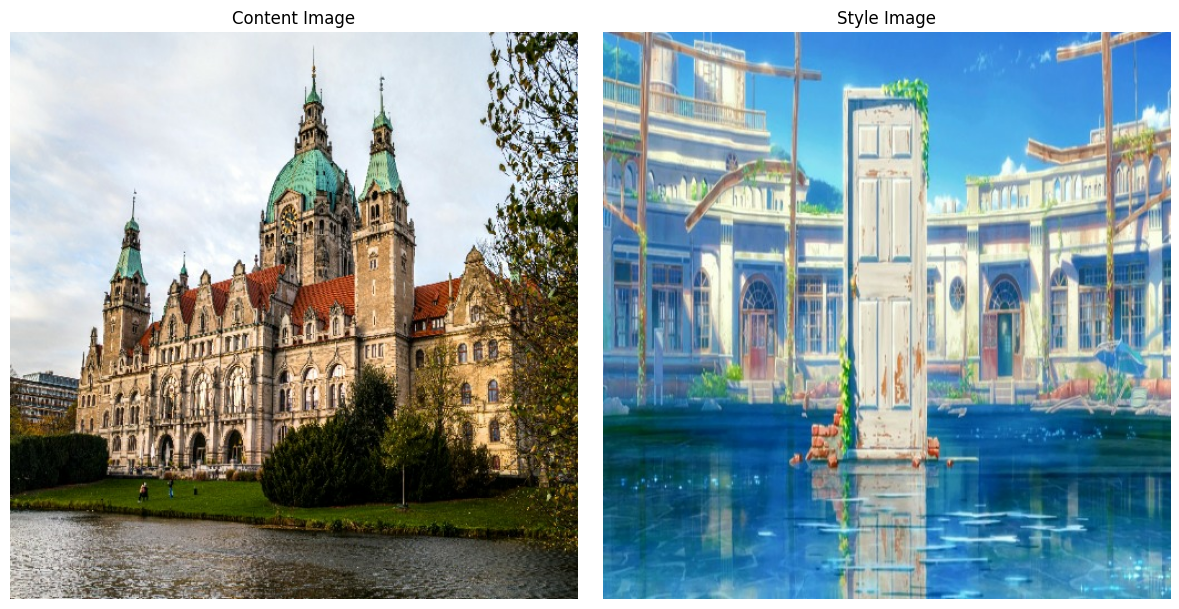

In [3]:
# 2. Image Loading and Preprocessing

def load_and_preprocess_image(image_path, target_size=(512, 512)):
    """Load and preprocess image for VGG19."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.vgg19.preprocess_input(img)
    return tf.expand_dims(img, axis=0)

def deprocess_image(processed_img):
    """Convert processed image back to displayable format."""
    img = processed_img.copy()
    if len(img.shape) == 4:
        img = img[0]
    
    # Reverse VGG19 preprocessing
    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68
    img = img[:, :, ::-1]  # BGR to RGB
    
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# Load images
CONTENT_PATH = 'ContentImage_512x512.jpg'
STYLE_PATH = 'Animate_512x512.jpg'

content_image = load_and_preprocess_image(CONTENT_PATH)
style_image = load_and_preprocess_image(STYLE_PATH)

print(f"Content image shape: {content_image.shape}")
print(f"Style image shape: {style_image.shape}")

# Display images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(deprocess_image(content_image.numpy()))
axes[0].set_title('Content Image')
axes[0].axis('off')
axes[1].imshow(deprocess_image(style_image.numpy()))
axes[1].set_title('Style Image')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/input_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# 3. VGG19 Feature Extractor

# Define layers for style and content
CONTENT_LAYERS = ['block4_conv2']
STYLE_LAYERS = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

def build_vgg_model():
    """Build VGG19 model for feature extraction."""
    vgg = VGG19(weights='imagenet', include_top=False)
    vgg.trainable = False
    
    content_outputs = [vgg.get_layer(name).output for name in CONTENT_LAYERS]
    style_outputs = [vgg.get_layer(name).output for name in STYLE_LAYERS]
    
    model = Model(inputs=vgg.input, outputs=content_outputs + style_outputs)
    return model

vgg_model = build_vgg_model()
print("VGG19 model built successfully")


VGG19 model built successfully


In [5]:
# 4. Edge Detector Implementations

def compute_edge_map_sobel(image):
    """
    Compute edge magnitude using Sobel operators (CURRENT BASELINE).
    
    Sobel kernel emphasizes center pixels with weights [1,2,1].
    Good for noise reduction while detecting edges.
    """
    sobel_x = tf.constant([[-1, 0, 1], 
                           [-2, 0, 2], 
                           [-1, 0, 1]], dtype=tf.float32)
    sobel_y = tf.constant([[-1, -2, -1], 
                           [0, 0, 0], 
                           [1, 2, 1]], dtype=tf.float32)
    
    sobel_x = tf.reshape(sobel_x, [3, 3, 1, 1])
    sobel_y = tf.reshape(sobel_y, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    edges_x = tf.nn.conv2d(gray, sobel_x, strides=[1, 1, 1, 1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, sobel_y, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)
    return edge_magnitude


def compute_edge_map_prewitt(image):
    """
    Compute edge magnitude using Prewitt operators.
    
    Prewitt kernel uses uniform weights [1,1,1].
    Simpler than Sobel, may be more sensitive to noise.
    """
    prewitt_x = tf.constant([[-1, 0, 1], 
                             [-1, 0, 1], 
                             [-1, 0, 1]], dtype=tf.float32)
    prewitt_y = tf.constant([[-1, -1, -1], 
                             [0, 0, 0], 
                             [1, 1, 1]], dtype=tf.float32)
    
    prewitt_x = tf.reshape(prewitt_x, [3, 3, 1, 1])
    prewitt_y = tf.reshape(prewitt_y, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    edges_x = tf.nn.conv2d(gray, prewitt_x, strides=[1, 1, 1, 1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, prewitt_y, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)
    return edge_magnitude


def compute_edge_map_scharr(image):
    """
    Compute edge magnitude using Scharr operators.
    
    Scharr kernel [3,10,3] provides better rotational symmetry
    and more accurate gradient estimation than Sobel.
    """
    scharr_x = tf.constant([[-3, 0, 3], 
                            [-10, 0, 10], 
                            [-3, 0, 3]], dtype=tf.float32)
    scharr_y = tf.constant([[-3, -10, -3], 
                            [0, 0, 0], 
                            [3, 10, 3]], dtype=tf.float32)
    
    scharr_x = tf.reshape(scharr_x, [3, 3, 1, 1])
    scharr_y = tf.reshape(scharr_y, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    edges_x = tf.nn.conv2d(gray, scharr_x, strides=[1, 1, 1, 1], padding='SAME')
    edges_y = tf.nn.conv2d(gray, scharr_y, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.sqrt(tf.square(edges_x) + tf.square(edges_y) + 1e-6)
    return edge_magnitude


def compute_edge_map_laplacian(image):
    """
    Compute edge magnitude using Laplacian operator.
    
    Laplacian detects edges by finding zero-crossings in second derivative.
    Sensitive to noise but detects edges in all directions equally.
    """
    # Standard Laplacian kernel
    laplacian_kernel = tf.constant([[0, 1, 0], 
                                    [1, -4, 1], 
                                    [0, 1, 0]], dtype=tf.float32)
    
    laplacian_kernel = tf.reshape(laplacian_kernel, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    laplacian = tf.nn.conv2d(gray, laplacian_kernel, strides=[1, 1, 1, 1], padding='SAME')
    
    # Use absolute value for edge magnitude
    edge_magnitude = tf.abs(laplacian)
    return edge_magnitude


def compute_edge_map_laplacian_diag(image):
    """
    Compute edge magnitude using Laplacian operator with diagonal neighbors.
    
    This variant includes diagonal neighbors for better edge detection.
    """
    # Laplacian kernel with diagonals
    laplacian_kernel = tf.constant([[1, 1, 1], 
                                    [1, -8, 1], 
                                    [1, 1, 1]], dtype=tf.float32)
    
    laplacian_kernel = tf.reshape(laplacian_kernel, [3, 3, 1, 1])
    
    gray = tf.reduce_mean(image, axis=-1, keepdims=True)
    
    laplacian = tf.nn.conv2d(gray, laplacian_kernel, strides=[1, 1, 1, 1], padding='SAME')
    
    edge_magnitude = tf.abs(laplacian)
    return edge_magnitude


# Dictionary of edge detectors
EDGE_DETECTORS = {
    'Sobel': compute_edge_map_sobel,
    'Prewitt': compute_edge_map_prewitt,
    'Scharr': compute_edge_map_scharr,
    'Laplacian': compute_edge_map_laplacian,
    'Laplacian_Diag': compute_edge_map_laplacian_diag
}

print("Edge detectors defined:")
for name in EDGE_DETECTORS.keys():
    print(f"  - {name}")

Edge detectors defined:
  - Sobel
  - Prewitt
  - Scharr
  - Laplacian
  - Laplacian_Diag


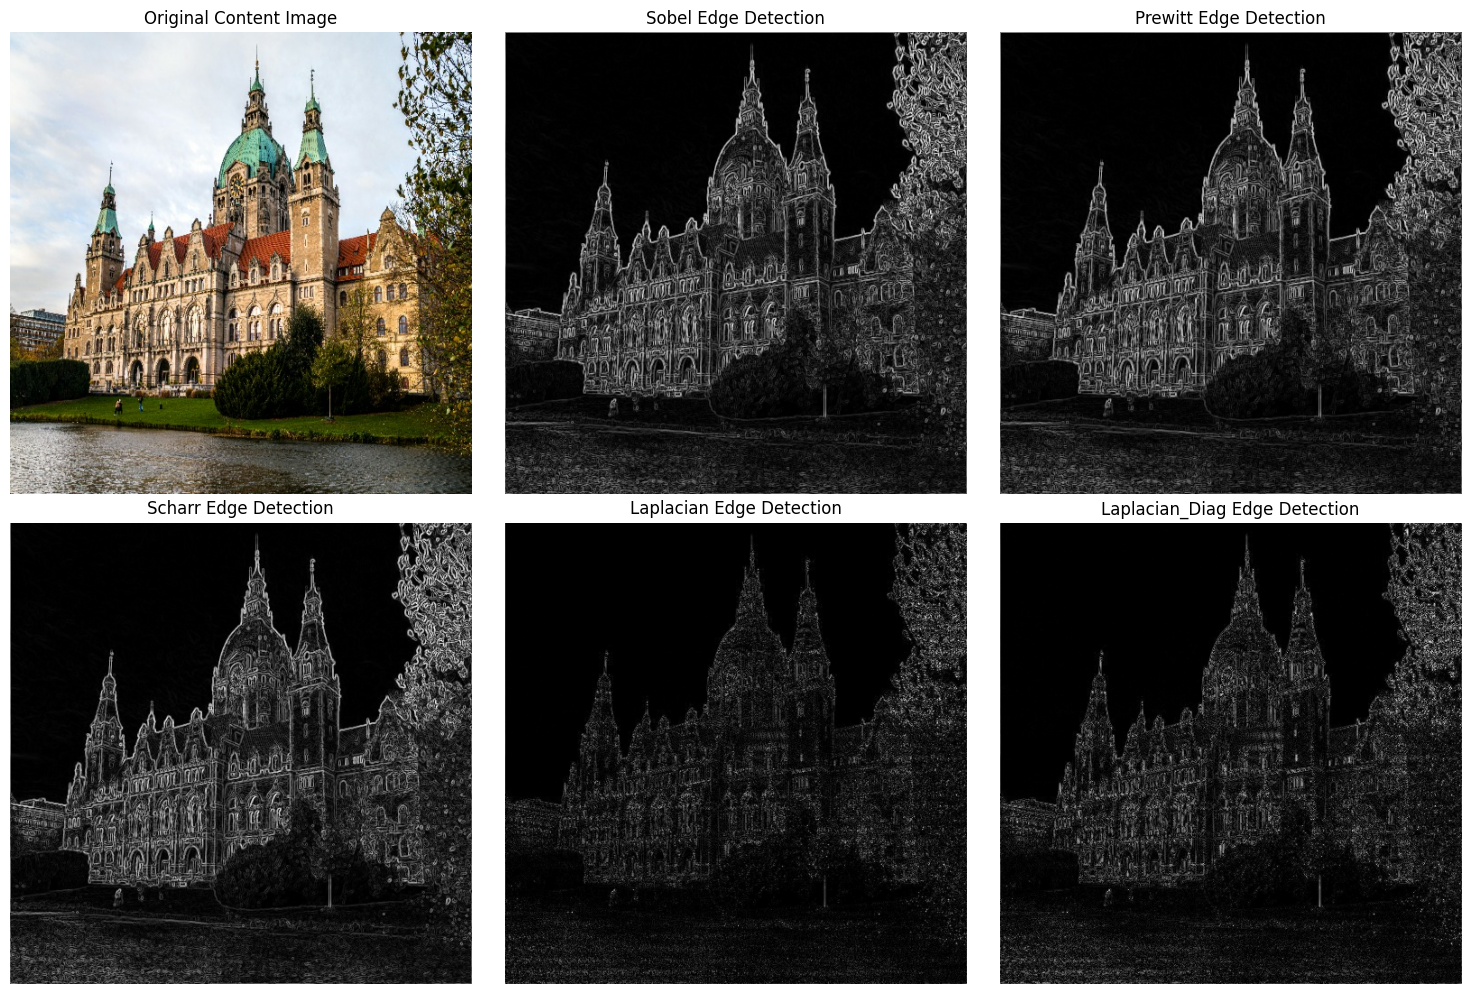

In [6]:
# 5. Visualize Edge Detection Results

# Compare edge detection on content image
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Original image
original = deprocess_image(content_image.numpy())
axes[0].imshow(original)
axes[0].set_title('Original Content Image')
axes[0].axis('off')

# Edge detection results
for i, (name, detector) in enumerate(EDGE_DETECTORS.items()):
    edge_map = detector(content_image).numpy()[0, :, :, 0]
    axes[i+1].imshow(edge_map, cmap='gray')
    axes[i+1].set_title(f'{name} Edge Detection')
    axes[i+1].axis('off')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/edge_detection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
# 6. Loss Functions

def gram_matrix(tensor):
    """Compute Gram matrix for style representation."""
    batch, h, w, c = tensor.shape
    features = tf.reshape(tensor, [batch, h * w, c])
    gram = tf.matmul(features, features, transpose_a=True)
    return gram / tf.cast(h * w * c, tf.float32)

def content_loss(content_features, generated_features):
    """Compute content loss."""
    return tf.reduce_mean(tf.square(content_features - generated_features))

def style_loss(style_features, generated_features):
    """Compute style loss."""
    style_gram = gram_matrix(style_features)
    generated_gram = gram_matrix(generated_features)
    return tf.reduce_mean(tf.square(style_gram - generated_gram))

def edge_loss_with_detector(content_image, generated_image, edge_detector_fn):
    """Compute edge preservation loss using specified edge detector."""
    content_edges = edge_detector_fn(content_image)
    generated_edges = edge_detector_fn(generated_image)
    return tf.reduce_mean(tf.square(content_edges - generated_edges))

def box_filter(image, radius):
    """Apply box filter for guided filter."""
    kernel_size = 2 * radius + 1
    kernel = tf.ones([kernel_size, kernel_size, 1, 1], dtype=tf.float32)
    kernel = kernel / (kernel_size * kernel_size)
    
    channels = tf.split(image, num_or_size_splits=image.shape[-1], axis=-1)
    filtered_channels = []
    for channel in channels:
        filtered = tf.nn.conv2d(channel, kernel, strides=[1, 1, 1, 1], padding='SAME')
        filtered_channels.append(filtered)
    return tf.concat(filtered_channels, axis=-1)

def guided_filter(guidance, source, radius=4, epsilon=0.01):
    """Apply guided filter for edge-preserving smoothing."""
    mean_g = box_filter(guidance, radius)
    mean_s = box_filter(source, radius)
    
    cov_gs = box_filter(guidance * source, radius) - mean_g * mean_s
    var_g = box_filter(guidance * guidance, radius) - mean_g * mean_g
    
    a = cov_gs / (var_g + epsilon)
    b = mean_s - a * mean_g
    
    mean_a = box_filter(a, radius)
    mean_b = box_filter(b, radius)
    
    return mean_a * guidance + mean_b

def surface_loss(content_image, generated_image, radius=4, epsilon=0.01):
    """Compute surface smoothing loss."""
    smoothed = guided_filter(content_image, generated_image, radius, epsilon)
    return tf.reduce_mean(tf.square(generated_image - smoothed))

print("Loss functions defined successfully")

Loss functions defined successfully


In [8]:
# 7. Total Loss with Configurable Edge Detector

def compute_total_loss(generated_image, content_image, style_image, vgg_model, weights, edge_detector_fn):
    """
    Compute total loss with configurable edge detector.
    
    Args:
        generated_image: Current generated image
        content_image: Original content image
        style_image: Style reference image
        vgg_model: VGG19 feature extractor
        weights: Dictionary of loss weights
        edge_detector_fn: Edge detection function to use
    
    Returns:
        total_loss, loss_dict
    """
    # Extract features
    input_tensor = tf.concat([content_image, style_image, generated_image], axis=0)
    features = vgg_model(input_tensor)
    
    num_content_layers = len(CONTENT_LAYERS)
    content_features = features[:num_content_layers]
    style_features = features[num_content_layers:]
    
    # Content loss
    c_loss = 0
    for i, layer_features in enumerate(content_features):
        content_feat = layer_features[0:1]
        generated_feat = layer_features[2:3]
        c_loss += content_loss(content_feat, generated_feat)
    c_loss /= len(CONTENT_LAYERS)
    
    # Style loss
    s_loss = 0
    for i, layer_features in enumerate(style_features):
        style_feat = layer_features[1:2]
        generated_feat = layer_features[2:3]
        s_loss += style_loss(style_feat, generated_feat)
    s_loss /= len(STYLE_LAYERS)
    
    # Total variation loss
    tv_loss = tf.image.total_variation(generated_image)
    
    # Edge loss with specified detector
    e_loss = edge_loss_with_detector(content_image, generated_image, edge_detector_fn) if weights['edge'] > 0 else 0
    
    # Surface loss
    surf_loss = surface_loss(content_image, generated_image) if weights['surface'] > 0 else 0
    
    # Total weighted loss
    total = (weights['content'] * c_loss + 
             weights['style'] * s_loss + 
             weights['tv'] * tv_loss +
             weights['edge'] * e_loss +
             weights['surface'] * surf_loss)
    
    loss_dict = {
        'total': float(total),
        'content': float(c_loss),
        'style': float(s_loss),
        'tv': float(tv_loss),
        'edge': float(e_loss) if weights['edge'] > 0 else 0,
        'surface': float(surf_loss) if weights['surface'] > 0 else 0
    }
    
    return total, loss_dict

In [9]:
# 8. Evaluation Metrics

from skimage.metrics import structural_similarity as ssim
from skimage.feature import canny
import cv2

def compute_edge_ssim(original, generated):
    """Compute Edge SSIM between original and generated images."""
    if len(original.shape) == 3:
        orig_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
        gen_gray = cv2.cvtColor(generated, cv2.COLOR_RGB2GRAY)
    else:
        orig_gray = original
        gen_gray = generated
    
    orig_edges = canny(orig_gray, sigma=1.0).astype(float)
    gen_edges = canny(gen_gray, sigma=1.0).astype(float)
    
    score = ssim(orig_edges, gen_edges, data_range=1.0)
    return score

def compute_flatness(image):
    """Compute flatness score using Laplacian variance."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    variance = laplacian.var()
    flatness = 1.0 / (1.0 + variance / 500.0)
    return flatness

def compute_color_variance(image, patch_size=8):
    """Compute mean color variance across patches."""
    h, w, c = image.shape
    variances = []
    
    for i in range(0, h - patch_size, patch_size):
        for j in range(0, w - patch_size, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size, :]
            var = np.var(patch)
            variances.append(var)
    
    return np.mean(variances)

def compute_gradient_magnitude(image):
    """Compute mean gradient magnitude."""
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(float)
    else:
        gray = image.astype(float)
    
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    return np.mean(magnitude)

def evaluate_image(original, generated):
    """Compute all evaluation metrics."""
    return {
        'edge_ssim': compute_edge_ssim(original, generated),
        'flatness': compute_flatness(generated),
        'color_variance': compute_color_variance(generated),
        'gradient_magnitude': compute_gradient_magnitude(generated)
    }

print("Evaluation metrics defined successfully")


Evaluation metrics defined successfully


In [10]:
# 9. L-BFGS Optimization

def run_optimization(content_image, style_image, vgg_model, weights, edge_detector_fn, 
                     edge_detector_name, iterations=20):
    """
    Run L-BFGS optimization with specified edge detector.
    """
    from scipy.optimize import fmin_l_bfgs_b
    
    print(f"\n{'='*60}")
    print(f"Running optimization with {edge_detector_name} edge detector")
    print(f"{'='*60}")
    
    img_shape = content_image.shape
    loss_history = []
    
    class Evaluator:
        def __init__(self):
            self.loss_value = None
            self.grads_value = None
        
        def loss(self, x):
            x = x.reshape(img_shape).astype('float32')
            x_tensor = tf.constant(x)
            
            with tf.GradientTape() as tape:
                tape.watch(x_tensor)
                loss, loss_dict = compute_total_loss(
                    x_tensor, content_image, style_image, 
                    vgg_model, weights, edge_detector_fn
                )
            
            grads = tape.gradient(loss, x_tensor)
            
            self.loss_value = float(loss)
            self.grads_value = grads.numpy().flatten().astype('float64')
            loss_history.append(self.loss_value)
            
            return self.loss_value
        
        def grads(self, x):
            return self.grads_value
    
    evaluator = Evaluator()
    x = content_image.numpy().flatten().astype('float64')
    
    start_time = time.time()
    
    for i in range(iterations):
        x, loss, info = fmin_l_bfgs_b(
            evaluator.loss,
            x,
            fprime=evaluator.grads,
            maxfun=20
        )
        print(f"  Iteration {i+1}/{iterations}: Loss = {loss:.4f}")
    
    elapsed_time = time.time() - start_time
    
    result_image = x.reshape(img_shape)
    
    return result_image, loss_history, elapsed_time


In [11]:
# 10. Experiment Configuration and Execution

# Edge+Surface Configuration (to test edge detection effectiveness)
EXPERIMENT_WEIGHTS = {
    'content': 2.5e-8,
    'style': 1e-4,
    'tv': 1e-6,
    'edge': 40000,      # Enabled to test edge detectors
    'surface': 10000,
}

print("Experiment weights:")
for k, v in EXPERIMENT_WEIGHTS.items():
    print(f"  {k}: {v}")

# Also run a baseline without edge loss for comparison
BASELINE_WEIGHTS = {
    'content': 2.5e-8,
    'style': 1e-4,
    'tv': 1e-6,
    'edge': 0,          # Disabled
    'surface': 10000,
}


# Define experiments
EXPERIMENTS = [
    {'name': 'No_Edge_Loss', 'detector': None, 'detector_fn': None},
    {'name': 'Sobel', 'detector': 'Sobel', 'detector_fn': compute_edge_map_sobel},
    {'name': 'Prewitt', 'detector': 'Prewitt', 'detector_fn': compute_edge_map_prewitt},
    {'name': 'Scharr', 'detector': 'Scharr', 'detector_fn': compute_edge_map_scharr},
    {'name': 'Laplacian', 'detector': 'Laplacian', 'detector_fn': compute_edge_map_laplacian},
    {'name': 'Laplacian_Diag', 'detector': 'Laplacian_Diag', 'detector_fn': compute_edge_map_laplacian_diag},
]

print(f"\nTotal experiments to run: {len(EXPERIMENTS)}")
for exp in EXPERIMENTS:
    print(f"  - {exp['name']}")

Experiment weights:
  content: 2.5e-08
  style: 0.0001
  tv: 1e-06
  edge: 40000
  surface: 10000

Total experiments to run: 6
  - No_Edge_Loss
  - Sobel
  - Prewitt
  - Scharr
  - Laplacian
  - Laplacian_Diag


In [12]:
# Run all experiments
results = []
original_image = deprocess_image(content_image.numpy())

for exp in EXPERIMENTS:
    print(f"\n{'#'*70}")
    print(f"# EXPERIMENT: {exp['name']}")
    print(f"{'#'*70}")
    
    try:
        if exp['detector'] is None:
            # No edge loss baseline
            weights = BASELINE_WEIGHTS
            edge_detector_fn = compute_edge_map_sobel  # Won't be used since edge weight is 0
        else:
            weights = EXPERIMENT_WEIGHTS
            edge_detector_fn = exp['detector_fn']
        
        result_image, loss_history, elapsed_time = run_optimization(
            content_image, style_image, vgg_model, weights,
            edge_detector_fn, exp['name'], iterations=20
        )
        
        # Deprocess and evaluate
        output_image = deprocess_image(result_image)
        metrics = evaluate_image(original_image, output_image)
        
        # Store results
        result = {
            'name': exp['name'],
            'detector': exp['detector'] if exp['detector'] else 'None',
            'time_seconds': elapsed_time,
            'final_loss': loss_history[-1],
            'edge_ssim': metrics['edge_ssim'],
            'flatness': metrics['flatness'],
            'color_variance': metrics['color_variance'],
            'gradient_magnitude': metrics['gradient_magnitude'],
            'loss_history': loss_history,
            'output_image': output_image
        }
        results.append(result)
        
        # Save individual result image
        plt.figure(figsize=(8, 8))
        plt.imshow(output_image)
        plt.title(f"{exp['name']}\nEdge SSIM: {metrics['edge_ssim']:.3f}, Flatness: {metrics['flatness']:.3f}")
        plt.axis('off')
        plt.savefig(f"{RESULTS_DIR}/{exp['name']}.png", dpi=150, bbox_inches='tight')
        plt.close()
        
        print(f"\n  Results for {exp['name']}:")
        print(f"    Time: {elapsed_time:.2f} seconds")
        print(f"    Final Loss: {loss_history[-1]:.4f}")
        print(f"    Edge SSIM: {metrics['edge_ssim']:.4f}")
        print(f"    Flatness: {metrics['flatness']:.4f}")
        
    except Exception as e:
        print(f"  ERROR in {exp['name']}: {str(e)}")
        import traceback
        traceback.print_exc()
        continue

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED")
print("="*70)


######################################################################
# EXPERIMENT: No_Edge_Loss
######################################################################

Running optimization with No_Edge_Loss edge detector
  Iteration 1/20: Loss = 5282.1626
  Iteration 2/20: Loss = 1698.4294
  Iteration 3/20: Loss = 1027.0781
  Iteration 4/20: Loss = 733.6086
  Iteration 5/20: Loss = 558.4683
  Iteration 6/20: Loss = 454.7895
  Iteration 7/20: Loss = 391.6178
  Iteration 8/20: Loss = 341.4981
  Iteration 9/20: Loss = 308.1529
  Iteration 10/20: Loss = 284.2487
  Iteration 11/20: Loss = 262.8336
  Iteration 12/20: Loss = 245.9134
  Iteration 13/20: Loss = 224.7079
  Iteration 14/20: Loss = 209.7129
  Iteration 15/20: Loss = 191.8385
  Iteration 16/20: Loss = 179.1906
  Iteration 17/20: Loss = 168.1627
  Iteration 18/20: Loss = 159.2087
  Iteration 19/20: Loss = 152.3630
  Iteration 20/20: Loss = 146.4786

  Results for No_Edge_Loss:
    Time: 195.40 seconds
    Final Loss: 146.4786
   

Edge Detector        Time(s)    Loss         Edge SSIM    Flatness   Color Var   
--------------------------------------------------------------------------------
No_Edge_Loss         195.40     146.4786     0.8124       0.0972     1223.53     
Sobel                195.73     208765.1250  0.9942       0.0755     1362.29     
Prewitt              194.91     201395.8750  0.9938       0.0755     1362.26     
Scharr               194.61     226843.3125  0.9912       0.0756     1361.08     
Laplacian            193.13     160984.0938  0.9609       0.0758     1362.32     
Laplacian_Diag       193.34     215466.8594  0.9763       0.0757     1360.49     
Results saved to results_edge_detector_comparison/edge_detector_comparison_results.csv


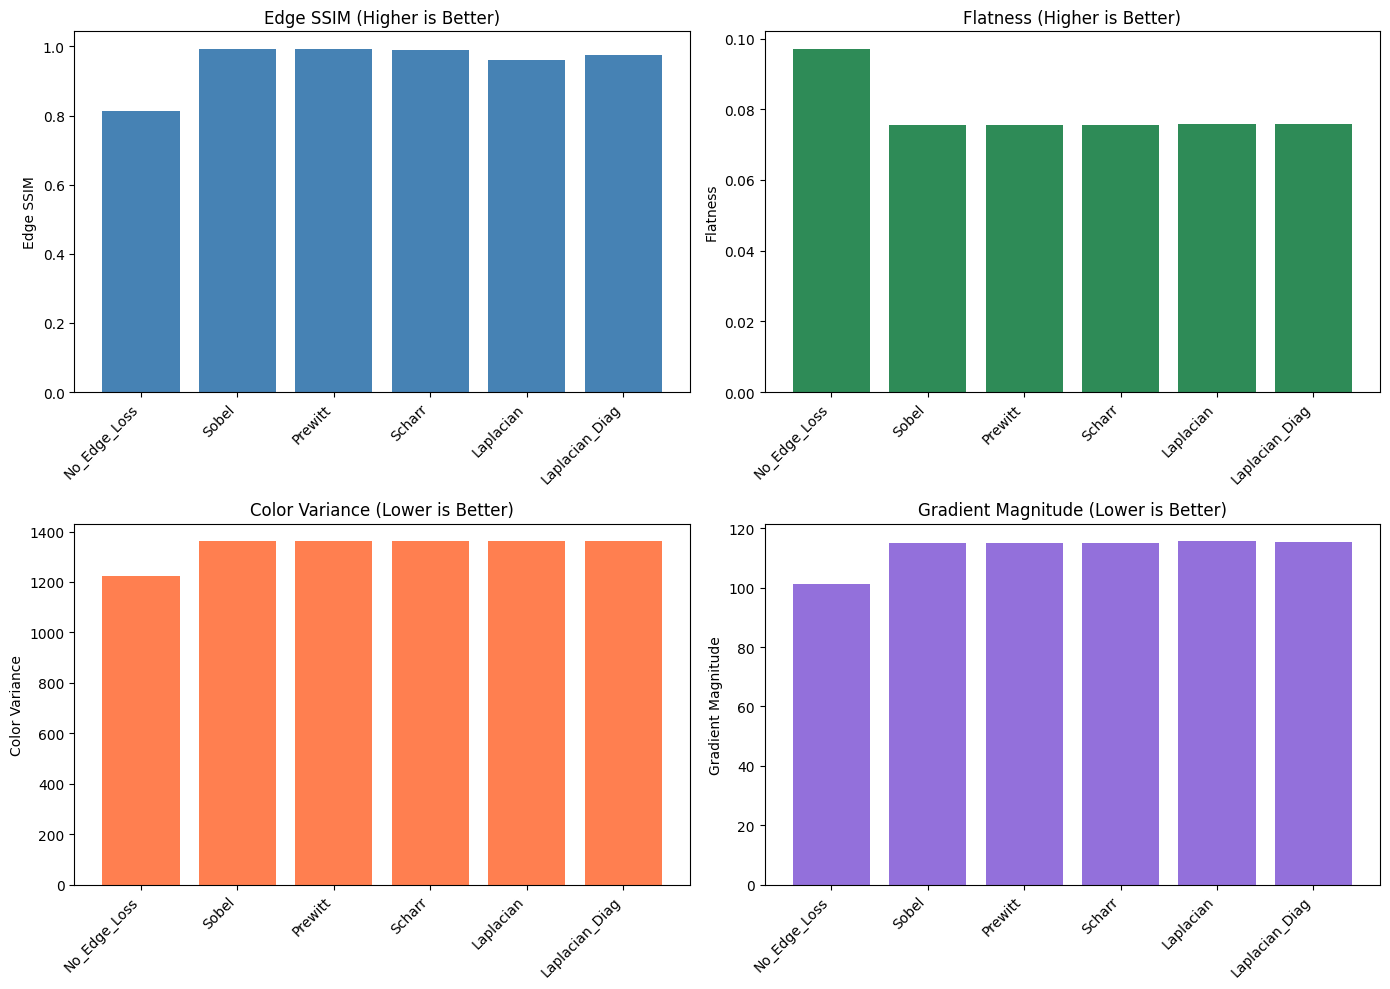

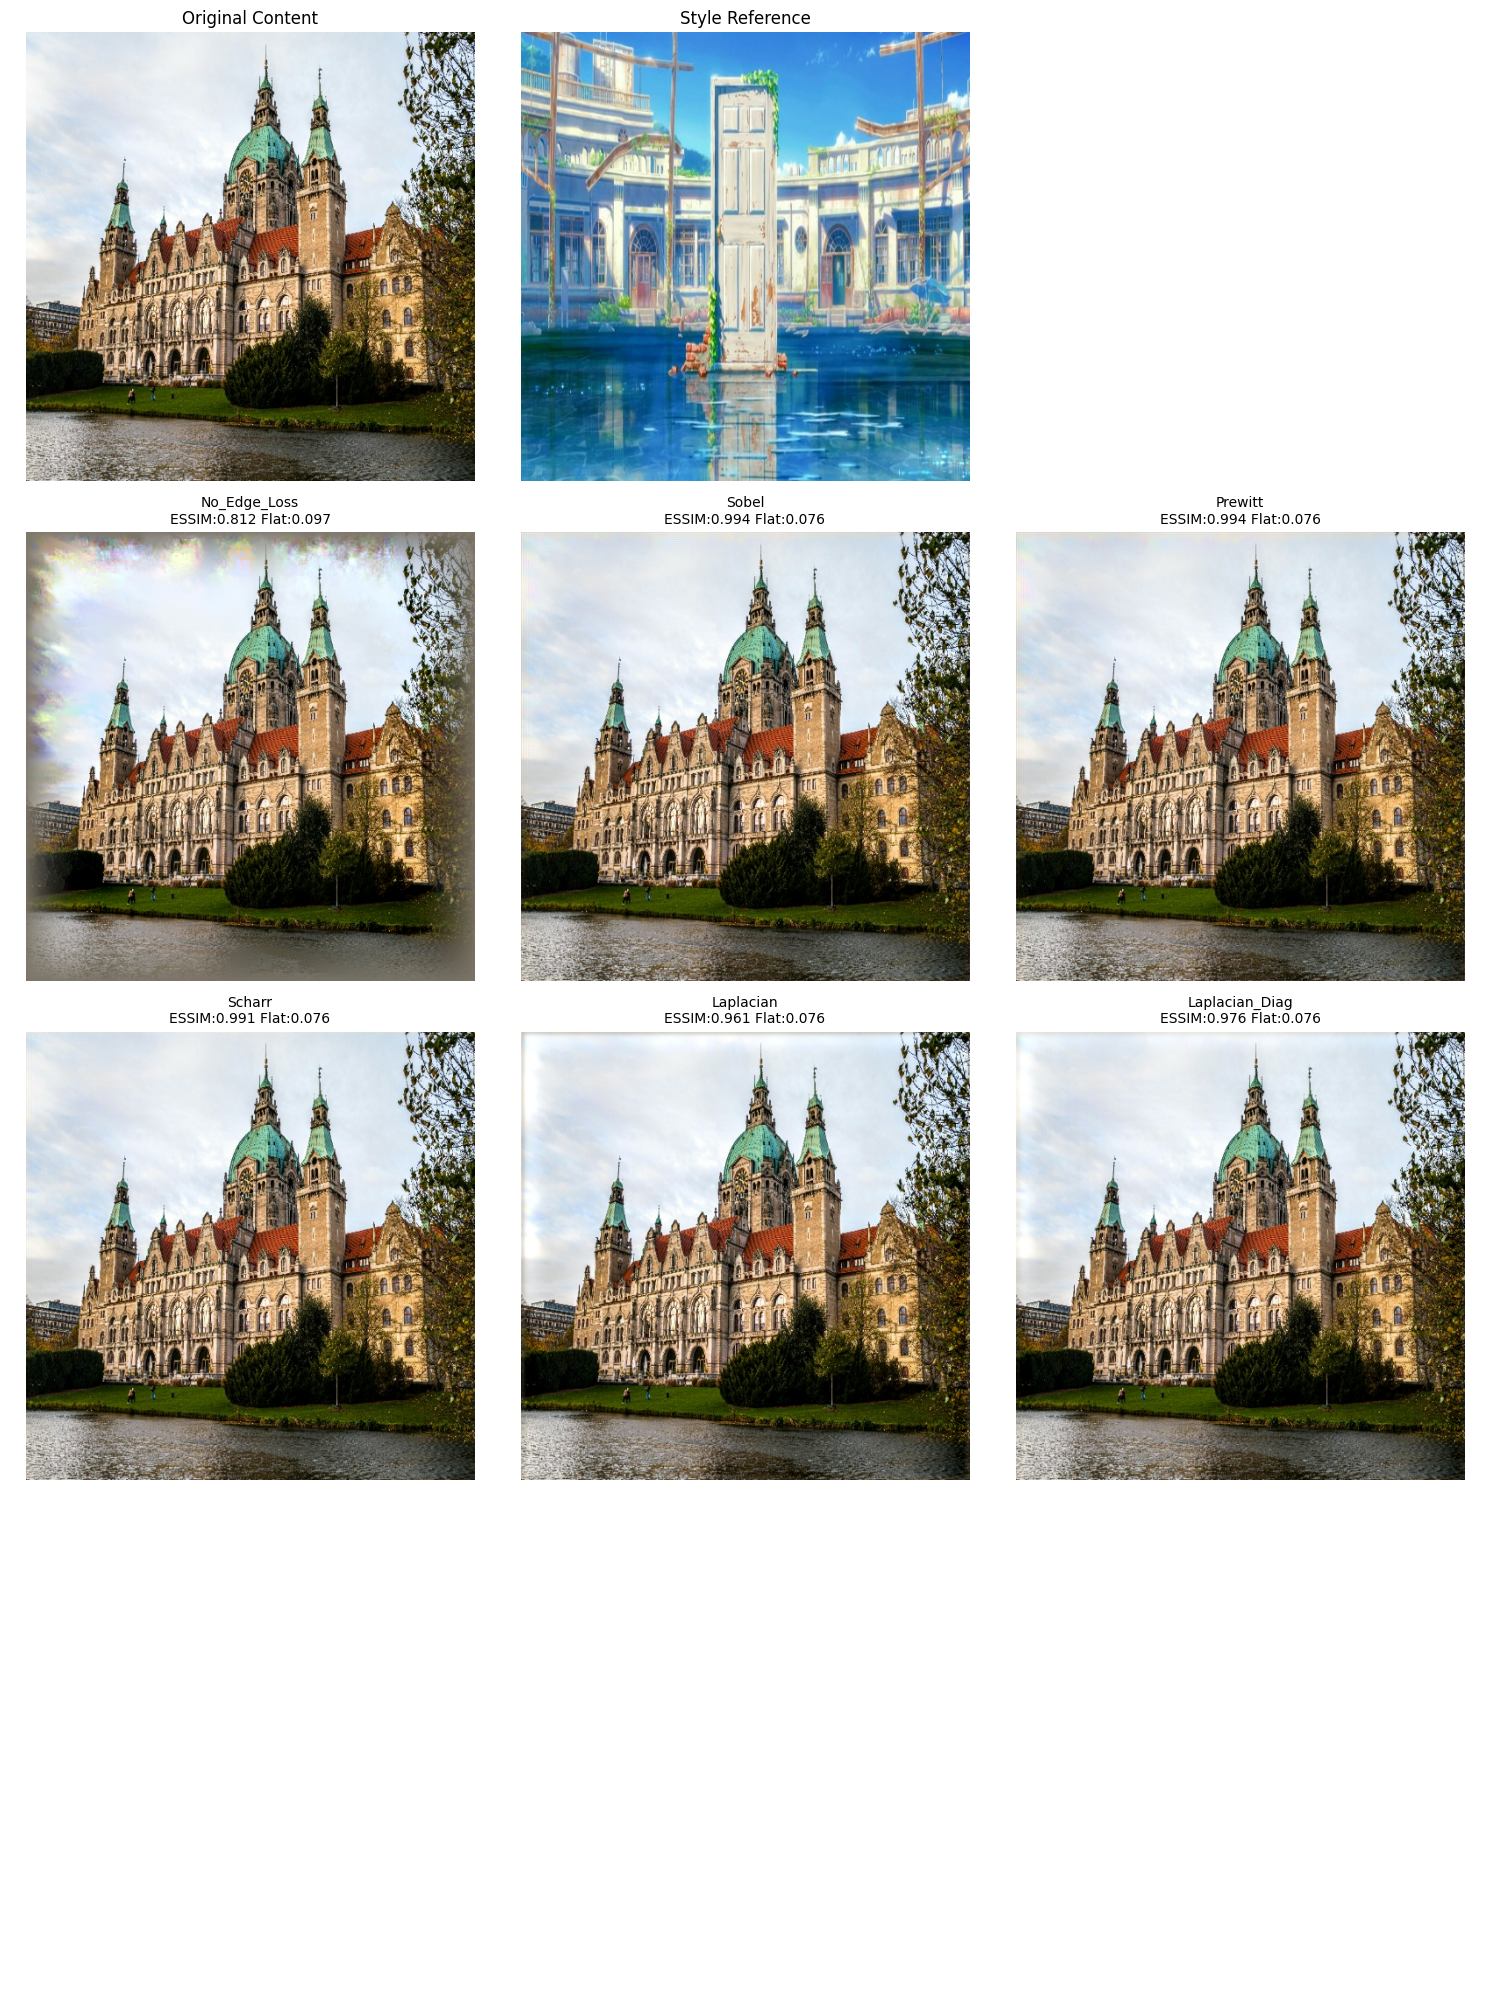

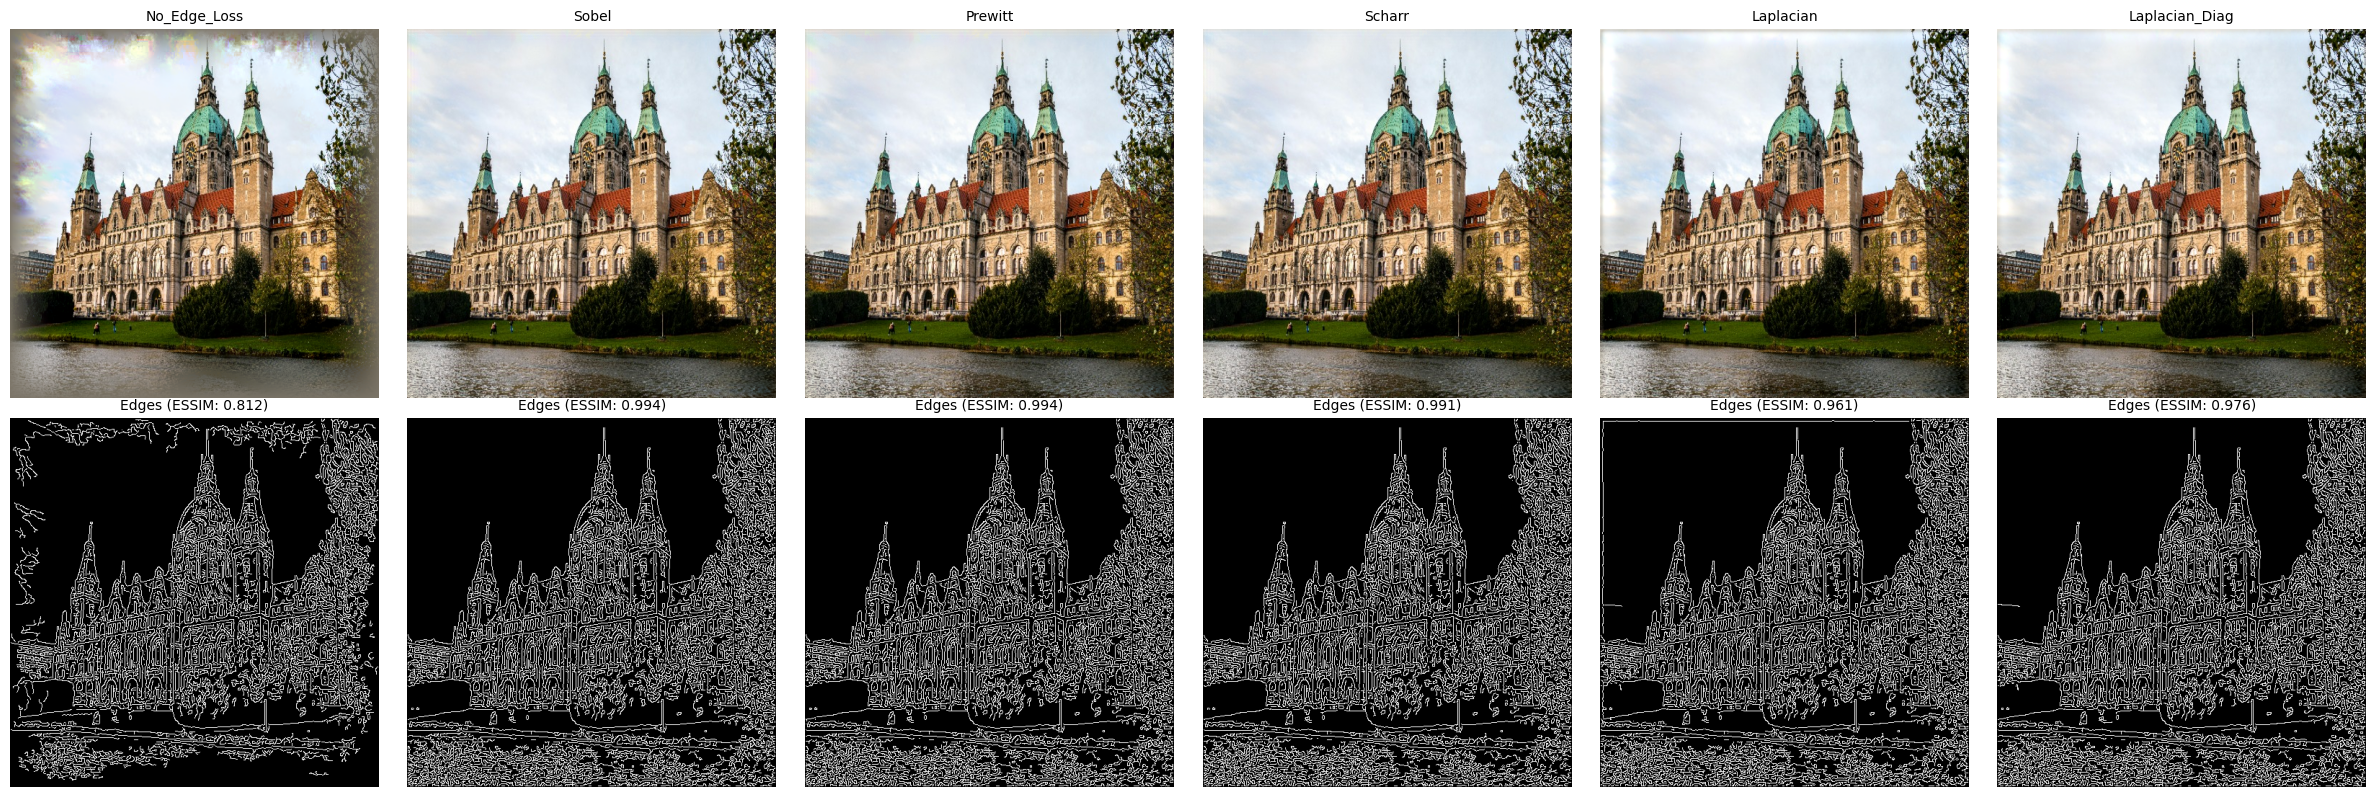

In [13]:
# 11. Results Analysis and Visualization

header = f"{'Edge Detector':<20} {'Time(s)':<10} {'Loss':<12} {'Edge SSIM':<12} {'Flatness':<10} {'Color Var':<12}"
print(header)
print("-" * 80)

for r in results:
    print(f"{r['name']:<20} {r['time_seconds']:<10.2f} {r['final_loss']:<12.4f} {r['edge_ssim']:<12.4f} {r['flatness']:<10.4f} {r['color_variance']:<12.2f}")


# Save results to CSV
csv_path = f"{RESULTS_DIR}/edge_detector_comparison_results.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Edge_Detector', 'Time_Seconds', 'Final_Loss', 'Edge_SSIM', 
                     'Flatness', 'Color_Variance', 'Gradient_Magnitude'])
    for r in results:
        writer.writerow([
            r['name'], r['time_seconds'], r['final_loss'], r['edge_ssim'],
            r['flatness'], r['color_variance'], r['gradient_magnitude']
        ])
print(f"Results saved to {csv_path}")


# Plot metrics comparison bar chart
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = [r['name'] for r in results]
x = np.arange(len(names))

# Edge SSIM
axes[0, 0].bar(x, [r['edge_ssim'] for r in results], color='steelblue')
axes[0, 0].set_ylabel('Edge SSIM')
axes[0, 0].set_title('Edge SSIM (Higher is Better)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(names, rotation=45, ha='right')

# Flatness
axes[0, 1].bar(x, [r['flatness'] for r in results], color='seagreen')
axes[0, 1].set_ylabel('Flatness')
axes[0, 1].set_title('Flatness (Higher is Better)')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(names, rotation=45, ha='right')

# Color Variance
axes[1, 0].bar(x, [r['color_variance'] for r in results], color='coral')
axes[1, 0].set_ylabel('Color Variance')
axes[1, 0].set_title('Color Variance (Lower is Better)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(names, rotation=45, ha='right')

# Gradient Magnitude
axes[1, 1].bar(x, [r['gradient_magnitude'] for r in results], color='mediumpurple')
axes[1, 1].set_ylabel('Gradient Magnitude')
axes[1, 1].set_title('Gradient Magnitude (Lower is Better)')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(names, rotation=45, ha='right')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/metrics_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


# Visual comparison grid
n_results = len(results)
cols = 3
rows = (n_results + cols) // cols + 1

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
axes = axes.flatten()

# Show original content image
axes[0].imshow(original_image)
axes[0].set_title('Original Content', fontsize=12)
axes[0].axis('off')

# Show style image
axes[1].imshow(deprocess_image(style_image.numpy()))
axes[1].set_title('Style Reference', fontsize=12)
axes[1].axis('off')

# Empty slot
axes[2].axis('off')

# Show results
for i, r in enumerate(results):
    ax = axes[cols + i]
    ax.imshow(r['output_image'])
    ax.set_title(f"{r['name']}\nESSIM:{r['edge_ssim']:.3f} Flat:{r['flatness']:.3f}", fontsize=10)
    ax.axis('off')

# Hide unused axes
for i in range(cols + len(results), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/visual_comparison_grid.png", dpi=150, bbox_inches='tight')
plt.show()


# Edge detection comparison on generated images
fig, axes = plt.subplots(2, len(results), figsize=(4*len(results), 8))

for i, r in enumerate(results):
    # Top row: generated images
    axes[0, i].imshow(r['output_image'])
    axes[0, i].set_title(f"{r['name']}", fontsize=10)
    axes[0, i].axis('off')
    
    # Bottom row: edge maps of generated images
    gray = cv2.cvtColor(r['output_image'], cv2.COLOR_RGB2GRAY)
    edges = canny(gray, sigma=1.0)
    axes[1, i].imshow(edges, cmap='gray')
    axes[1, i].set_title(f"Edges (ESSIM: {r['edge_ssim']:.3f})", fontsize=10)
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Generated Image', fontsize=12)
axes[1, 0].set_ylabel('Edge Map', fontsize=12)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/edge_maps_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# 12. Conclusions

# Find best results (excluding No_Edge_Loss baseline)
edge_results = [r for r in results if r['name'] != 'No_Edge_Loss']

if edge_results:
    best_edge_ssim = max(edge_results, key=lambda x: x['edge_ssim'])
    best_flatness = max(edge_results, key=lambda x: x['flatness'])
    
    # Get baseline for comparison
    no_edge = next((r for r in results if r['name'] == 'No_Edge_Loss'), None)
    sobel = next((r for r in results if r['name'] == 'Sobel'), None)

print("\n" + "="*70)
print("EXPERIMENT B: EDGE DETECTOR COMPARISON - CONCLUSIONS")
print("="*70)

if edge_results:
    print(f"\nBest Edge SSIM: {best_edge_ssim['name']} ({best_edge_ssim['edge_ssim']:.4f})")
    print(f"Best Flatness: {best_flatness['name']} ({best_flatness['flatness']:.4f})")

print("\n" + "-"*70)
print("Comparison with No Edge Loss Baseline:")
if no_edge:
    print(f"  No Edge Loss - Edge SSIM: {no_edge['edge_ssim']:.4f}, Flatness: {no_edge['flatness']:.4f}")
if sobel:
    print(f"  Sobel        - Edge SSIM: {sobel['edge_ssim']:.4f}, Flatness: {sobel['flatness']:.4f}")
    if no_edge:
        improvement = ((sobel['edge_ssim'] - no_edge['edge_ssim']) / no_edge['edge_ssim']) * 100
        print(f"  Improvement with Sobel: {improvement:+.1f}% Edge SSIM")


print(f"\nResults saved to: {RESULTS_DIR}/")


EXPERIMENT B: EDGE DETECTOR COMPARISON - CONCLUSIONS

Best Edge SSIM: Sobel (0.9942)
Best Flatness: Laplacian (0.0758)

----------------------------------------------------------------------
Comparison with No Edge Loss Baseline:
  No Edge Loss - Edge SSIM: 0.8124, Flatness: 0.0972
  Sobel        - Edge SSIM: 0.9942, Flatness: 0.0755
  Improvement with Sobel: +22.4% Edge SSIM

Results saved to: results_edge_detector_comparison/
